In [1]:
# prompt: connect drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Load Dataset from Excel File

In [38]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/Thesis/version50k.xlsx')

print(df.head(5))

# Check for missing values
print(df.isnull().sum())

# Drop rows with missing values
df = df.dropna()

                                     Abuse Data Text  Aspects  Outcome
0  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...    Toxic        1
1  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...   Threat        0
2  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...  Obscene        0
3  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...   Insult        1
4  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...   Racism        0
Abuse Data Text        0
Aspects            39606
Outcome                0
dtype: int64


# Tokenize and Preprocess the Dataset

In [40]:
!pip install datasets

In [42]:
from transformers import BertTokenizer
from datasets import Dataset

# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Convert the 'Abuse Data Text' column to string type before creating the Dataset
df['Abuse Data Text'] = df['Abuse Data Text'].astype(str)

# Now create the Hugging Face Dataset
dataset = Dataset.from_pandas(df)

# Define a preprocessing function to tokenize the text and prepare labels
def preprocess_data(example):
    encoding = tokenizer(
        example['Abuse Data Text'],  # Column name for the text in your dataset
        padding='max_length',       # Pad sequences to the same length
        truncation=True,            # Truncate sequences that are too long
        max_length=128              # Maximum length of sequences
    )
    encoding["labels"] = example["Outcome"]  # Use 'Outcome' column as labels
    return encoding



In [43]:
# Apply the preprocessing function to the dataset
tokenized_dataset = dataset.map(preprocess_data, batched=True)

# Split the dataset into training and testing sets
tokenized_dataset = tokenized_dataset.train_test_split(test_size=0.2)

train_dataset = tokenized_dataset["train"]
test_dataset = tokenized_dataset["test"]

# Keep only the necessary columns for training
columns_to_keep = ["input_ids", "attention_mask", "labels"]
train_dataset = train_dataset.remove_columns([col for col in train_dataset.column_names if col not in columns_to_keep])
test_dataset = test_dataset.remove_columns([col for col in test_dataset.column_names if col not in columns_to_keep])

Map:   0%|          | 0/10394 [00:00<?, ? examples/s]

# Train the BERT Model

In [44]:
from transformers import BertForSequenceClassification, TrainingArguments, Trainer

# Load pre-trained BERT model for binary classification
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


# Define Metrics for Evaluation

In [45]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# Train the Model

In [ ]:
# Define the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.704000,0.701210,0.565176,0.722017,0.566329,0.995759
2,0.686700,0.684347,0.567100,0.723757,0.567100,1.000000


In [11]:
# Save the model and tokenizer
model.save_pretrained("./bert-toxic-classifier")
tokenizer.save_pretrained("./bert-toxic-classifier")

('./bert-toxic-classifier/tokenizer_config.json',
 './bert-toxic-classifier/special_tokens_map.json',
 './bert-toxic-classifier/vocab.txt',
 './bert-toxic-classifier/added_tokens.json')

# Inference

In [12]:
from transformers import pipeline

# Load the trained model and tokenizer
classifier = pipeline("text-classification", model="./bert-toxic-classifier", tokenizer=tokenizer)

# Predict on new text
new_text = "এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত..."
prediction = classifier(new_text)
print(prediction)

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


[{'label': 'LABEL_0', 'score': 0.5488185882568359}]


# final

# Import Libraries and Load Dataset

In [30]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import TFBertModel, BertTokenizer
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:


# Load the dataset
df = pd.read_excel('/content/drive/MyDrive/Thesis/version50k.xlsx')

# Display the first few rows of the dataset
print(df.head())

                                     Abuse Data Text  Aspects  Outcome
0  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...    Toxic        1
1  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...   Threat        0
2  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...  Obscene        0
3  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...   Insult        1
4  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...   Racism        0


# Preprocess the Dataset

In [33]:
# Map labels to numeric values (if necessary)
labels = ['Toxic', 'Threat', 'Obscene', 'Insult', 'Racism']  # Multi-class labels
label_map = {label: idx for idx, label in enumerate(labels)}

# Map labels to integers
df['Aspects'] = df['Aspects'].map(label_map)

# Fill missing values in the text column (if any)
df['Abuse Data Text'] = df['Abuse Data Text'].fillna('')

# Split dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    df['Abuse Data Text'], df['Aspects'], test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")

Training samples: 40000, Validation samples: 10000


# Tokenize the Text

In [35]:
# Load pre-trained BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize the text data
max_length = 128  # Maximum sequence length for BERT
def tokenize_text(texts):
    # Convert all elements in 'texts' to strings
    # before passing them to the tokenizer.
    # This handles potential mixed data types and NaN values.
    texts = texts.astype(str).tolist()
    tokens = tokenizer.batch_encode_plus(
        texts, # Pass the stringified list
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors="tf"
    )
    return tokens

# Tokenize training and validation data
X_train_tokens = tokenize_text(X_train)
X_val_tokens = tokenize_text(X_val)

# Convert to TensorFlow tensors
y_train = tf.convert_to_tensor(y_train.values, dtype=tf.int32)
y_val = tf.convert_to_tensor(y_val.values, dtype=tf.int32)

/usr/local/lib/python3.10/dist-packages/tensorflow/python/framework/constant_op.py:108: RuntimeWarning: invalid value encountered in cast
  return ops.EagerTensor(value, ctx.device_name, dtype)


# Build the BERT Model

In [36]:
# Load pre-trained BERT model
bert_model = TFBertModel.from_pretrained('bert-base-uncased')

# Define input layers using Input()
input_ids = Input(shape=(max_length,), dtype=tf.int32, name="input_ids")
attention_mask = Input(shape=(max_length,), dtype=tf.int32, name="attention_mask")
token_type_ids = Input(shape=(max_length,), dtype=tf.int32, name="token_type_ids")

# Wrap bert_model call in a custom layer to handle Keras symbolic tensors
class BertLayer(tf.keras.layers.Layer):
    def __init__(self, bert_model):
        super(BertLayer, self).__init__()
        self.bert_model = bert_model

    def call(self, inputs):
        input_ids, attention_mask, token_type_ids = inputs
        bert_output = self.bert_model(
            input_ids,
            attention_mask=attention_mask,  # No need for tf.cast here
            token_type_ids=token_type_ids    # No need for tf.cast here
        )
        return bert_output.pooler_output  # Return pooled output

# Pass inputs through the custom BertLayer
bert_output = BertLayer(bert_model)([input_ids, attention_mask, token_type_ids])

# Use the pooled output for classification
pooled_output = Dropout(0.3)(bert_output)  # Add dropout for regularization
output = Dense(len(labels), activation='softmax')(pooled_output)  # Multi-class classification

# Define the model using the input layers
model = Model(inputs=[input_ids, attention_mask, token_type_ids], outputs=output)

# Compile the model
# Add this line before calling model.fit()
model.compile(optimizer=Adam(learning_rate=2e-5),
              loss='sparse_categorical_crossentropy',  # Use sparse for integer labels
              metrics=['accuracy'])

# Prepare inputs for the model
# Use validation data for validation_data
train_inputs = {
    'input_ids': X_train_tokens['input_ids'],
    'attention_mask': X_train_tokens['attention_mask'],
    'token_type_ids': X_train_tokens['token_type_ids']
}

val_inputs = {
    'input_ids': X_val_tokens['input_ids'],
    'attention_mask': X_val_tokens['attention_mask'],
    'token_type_ids': X_val_tokens['token_type_ids']
}

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

# Train the Model

In [37]:
# Prepare inputs for the model
train_inputs = {
    'input_ids': X_train_tokens['input_ids'],
    'attention_mask': X_train_tokens['attention_mask'],
    'token_type_ids': X_train_tokens['token_type_ids']
}

val_inputs = {
    'input_ids': X_val_tokens['input_ids'],
    'attention_mask': X_val_tokens['attention_mask'],
    'token_type_ids': X_val_tokens['token_type_ids']
}

# Train the model
history = model.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=3,
    batch_size=16
)

Epoch 1/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 374s 144ms/step - accuracy: 0.0418 - loss: nan - val_accuracy: 0.0425 - val_loss: nan
Epoch 2/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 362s 145ms/step - accuracy: 0.0420 - loss: nan - val_accuracy: 0.0425 - val_loss: nan
Epoch 3/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 371s 140ms/step - accuracy: 0.0420 - loss: nan - val_accuracy: 0.0425 - val_loss: nan


# Evaluate the Model

In [26]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(val_inputs, y_val)
print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}")

# Predict on validation set
y_pred_probs = model.predict(val_inputs)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate a classification report
print(classification_report(y_val, y_pred, target_names=labels))

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.1741 - loss: nan
Validation Loss: nan, Validation Accuracy: 0.18000000715255737
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step
              precision    recall  f1-score   support

       Toxic       0.23      1.00      0.37        23
      Threat       0.00      0.00      0.00        16
     Obscene       0.00      0.00      0.00        24
      Insult       0.00      0.00      0.00        19
      Racism       0.00      0.00      0.00        18

    accuracy                           0.23       100
   macro avg       0.05      0.20      0.07       100
weighted avg       0.05      0.23      0.09       100



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Confusion Matrix

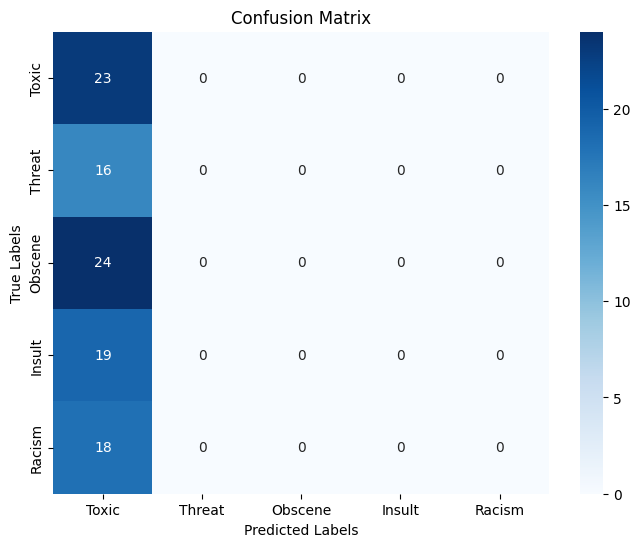

In [27]:
# Create a confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Save the Model

# OLD code

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

class AbusiveTextDataset(Dataset):
    def __init__(self, texts, aspects, labels, tokenizer, max_len=128):
        self.texts = texts
        self.aspects = aspects
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Combine text and aspect with SEP token
        combined_text = f"{str(self.texts.iloc[idx])} [SEP] {str(self.aspects.iloc[idx])}"

        encoding = self.tokenizer.encode_plus(
            combined_text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def train_bert_model(df, model_name='bert-base-multilingual-uncased', epochs=5, batch_size=16):
    # Preprocess and validate data
    print("Dataset shape:", df.shape)
    print("Columns:", df.columns)

    # Handle potential missing values
    df['Abuse Data Text'] = df['Abuse Data Text'].fillna('')
    df['Aspects'] = df['Aspects'].fillna('')

    # Encode labels
    label_encoder = LabelEncoder()
    try:
        labels = label_encoder.fit_transform(df['Outcome'])
    except Exception as e:
        print(f"Error in label encoding: {e}")
        print("Unique values in Outcome column:", df['Outcome'].unique())
        raise

    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        df[['Abuse Data Text', 'Aspects']],
        labels,
        test_size=0.2,
        random_state=42
    )

    # Initialize tokenizer and model with error handling
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=len(label_encoder.classes_)
        )
    except Exception as e:
        print(f"Error loading model/tokenizer: {e}")
        raise

    # Prepare datasets
    train_dataset = AbusiveTextDataset(
        X_train['Abuse Data Text'],
        X_train['Aspects'],
        y_train,
        tokenizer
    )
    val_dataset = AbusiveTextDataset(
        X_val['Abuse Data Text'],
        X_val['Aspects'],
        y_val,
        tokenizer
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Optimizer with AdamW from torch
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    # Training loop
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model.to(device)

    all_val_predictions = []
    all_val_labels = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_loss += loss.item()

            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_loss = 0
        val_predictions = []
        val_true_labels = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(
                    input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                val_loss += outputs.loss.item()

                predictions = torch.argmax(outputs.logits, dim=1).cpu().numpy()
                val_predictions.extend(predictions)
                val_true_labels.extend(labels.cpu().numpy())

        # Calculate metrics
        accuracy = accuracy_score(val_true_labels, val_predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(val_true_labels, val_predictions, average='weighted')

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Training Loss: {total_loss/len(train_loader):.4f}")
        print(f"Validation Loss: {val_loss/len(val_loader):.4f}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")

        all_val_predictions = val_predictions
        all_val_labels = val_true_labels

    # Final Detailed Metrics
    print("\nDetailed Classification Report:")
    print(classification_report(all_val_labels, all_val_predictions,
                                target_names=label_encoder.classes_))

    # Confusion Matrix
    cm = confusion_matrix(all_val_labels, all_val_predictions)
    plt.figure(figsize=(10,7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.close()

    return model, tokenizer, label_encoder

# Main execution
try:
    df = pd.read_excel('/content/drive/MyDrive/ResarchColab/demo.xlsx')
    model, tokenizer, label_encoder = train_bert_model(df)
except Exception as e:
    print(f"An error occurred: {e}")

Dataset shape: (499, 3)
Columns: Index(['Abuse Data Text', 'Aspects', 'Outcome'], dtype='object')


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda
Epoch 1/5
Training Loss: 0.6294
Validation Loss: 0.5317
Accuracy: 0.7700
Precision: 0.7774
Recall: 0.7700
F1-Score: 0.7718
Epoch 2/5
Training Loss: 0.3919
Validation Loss: 0.4365
Accuracy: 0.7900
Precision: 0.8016
Recall: 0.7900
F1-Score: 0.7919
Epoch 3/5
Training Loss: 0.3140
Validation Loss: 0.4296
Accuracy: 0.8100
Precision: 0.8497
Recall: 0.8100
F1-Score: 0.8114
Epoch 4/5
Training Loss: 0.2698
Validation Loss: 0.3815
Accuracy: 0.8300
Precision: 0.8368
Recall: 0.8300
F1-Score: 0.8313
Epoch 5/5
Training Loss: 0.2072
Validation Loss: 0.3917
Accuracy: 0.8500
Precision: 0.8531
Recall: 0.8500
F1-Score: 0.8508

Detailed Classification Report:
An error occurred: object of type 'numpy.int64' has no len()


In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

# Load dataset
dataset_url = 'https://docs.google.com/spreadsheets/d/1v8pvzCxwsj1vUkt4SN94M4mBGm4TPTZ32ZzRaqPPhI4/edit?usp=sharing'
data = pd.read_csv(dataset_url)

# Define a custom dataset class
class AbuseDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        inputs = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return {
            'input_ids': inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0),
            'labels': label
        }

# Preprocess data
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
texts = data['Abuse Data Text'].tolist()
labels = data['Outcome'].tolist()
dataset = AbuseDataset(texts, labels, tokenizer)

# Split dataset into training and evaluation sets
train_size = int(0.8 * len(dataset))
eval_size = len(dataset) - train_size
train_dataset, eval_dataset = torch.utils.data.random_split(dataset, [train_size, eval_size])

# Define model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy="epoch"
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset
)

# Train model
trainer.train()

# Save model
model.save_pretrained('./trained_model')
tokenizer.save_pretrained('./trained_model')

print("Model training completed and saved.")


ParserError: Error tokenizing data. C error: Expected 669 fields in line 82, saw 4101
